# Week 6 — CNN Inference: Kernels, Feature Maps, and Forward Passes

**Course:** Data Science for Electron Microscopy  
**Topic:** Convolutional Neural Networks — hands-on without training  
**Time estimate:** ~90–120 minutes  

---

## What you will do

1. Apply **hand-set kernels** (Sobel, Laplacian, Gaussian) to a synthetic grain microstructure and visualise the resulting feature maps.
2. **Design your own kernel** to detect a specific grain boundary orientation (exercise).
3. Run a **tiny randomly-initialised CNN forward pass** to understand tensor shapes and receptive fields — no training involved.

**No large downloads. No training. Runs entirely on CPU in under a minute.**

---

## Instructions

- Read each section, run the cell above it, then try the `(try this yourself)` lines.
- The **Exercise** cell ships with a **working version** — try to figure out what it does before running it.
- The `assert` statements at the end of the exercise check your understanding — if they pass, you got it right.
- A non-executable **Solution** cell (fenced code block in the markdown below the exercise) shows one correct answer.

In [1]:
# --- First cell: install / imports ---
# Colab: uncomment the pip line if needed
# !pip install torch numpy matplotlib scipy --quiet

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import torch
import torch.nn as nn

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print("Imports OK — torch", torch.__version__)

Imports OK — torch 2.7.1+cu126


---

## Part 1 — Build a synthetic grain microstructure

We need an image that looks like a real EM microstructure, but is generated entirely in Python so we have ground-truth labels.

We will create a 128×128 grayscale image with **five Voronoi grains** — different intensity in each grain, separated by sharp boundaries.

/tmp/ipykernel_2627906/569839592.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap5 = plt.cm.get_cmap('tab10', 5)


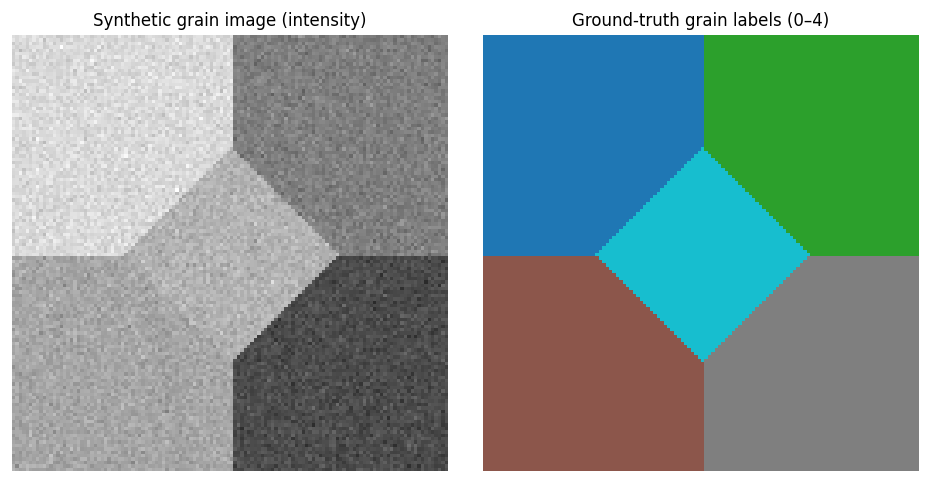

Image shape: (128, 128), dtype: float32
Intensity range: [0.165, 1.000]


In [2]:
# ── Build the synthetic grain image ──────────────────────────────────────────
H, W = 128, 128

# Seed points for 5 grains (row, col)
seeds = np.array([[32, 32], [32, 96], [96, 32], [96, 96], [64, 64]], dtype=float)

# Voronoi assignment: each pixel → nearest seed
yy, xx = np.mgrid[:H, :W]
pts = np.stack([yy.ravel(), xx.ravel()], axis=1)  # (N, 2)
dists = np.stack([
    np.sqrt((pts[:, 0] - s[0])**2 + (pts[:, 1] - s[1])**2)
    for s in seeds
], axis=1)  # (N, 5)
grain_id = np.argmin(dists, axis=1).reshape(H, W)  # 0..4

# Each grain gets a distinct average intensity + Gaussian noise
grain_intensities = [0.85, 0.50, 0.65, 0.30, 0.70]
image = np.zeros((H, W))
for g, intens in enumerate(grain_intensities):
    mask = grain_id == g
    image[mask] = intens + 0.04 * np.random.randn(np.sum(mask))

image = np.clip(image, 0.0, 1.0).astype(np.float32)

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Synthetic grain image (intensity)', fontsize=10)
axes[0].axis('off')

cmap5 = plt.cm.get_cmap('tab10', 5)
axes[1].imshow(grain_id, cmap=cmap5, vmin=0, vmax=4)
axes[1].set_title('Ground-truth grain labels (0–4)', fontsize=10)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {image.shape}, dtype: {image.dtype}')
print(f'Intensity range: [{image.min():.3f}, {image.max():.3f}]')

---

## Part 2 — Hand-set kernels as feature detectors

A kernel is just a small matrix of weights. When we *convolve* it with the image, each output pixel encodes how strongly the kernel's pattern was present at that location.

Three classic kernels:

| Kernel | What it detects |
|---|---|
| Vertical Sobel | Left–right intensity change (vertical boundary) |
| Horizontal Sobel | Top–bottom intensity change (horizontal boundary) |
| Laplacian | Any local peak or valley (boundary in any direction) |
| Gaussian (5×5) | Smoothed (noise-reduced) version of the image |

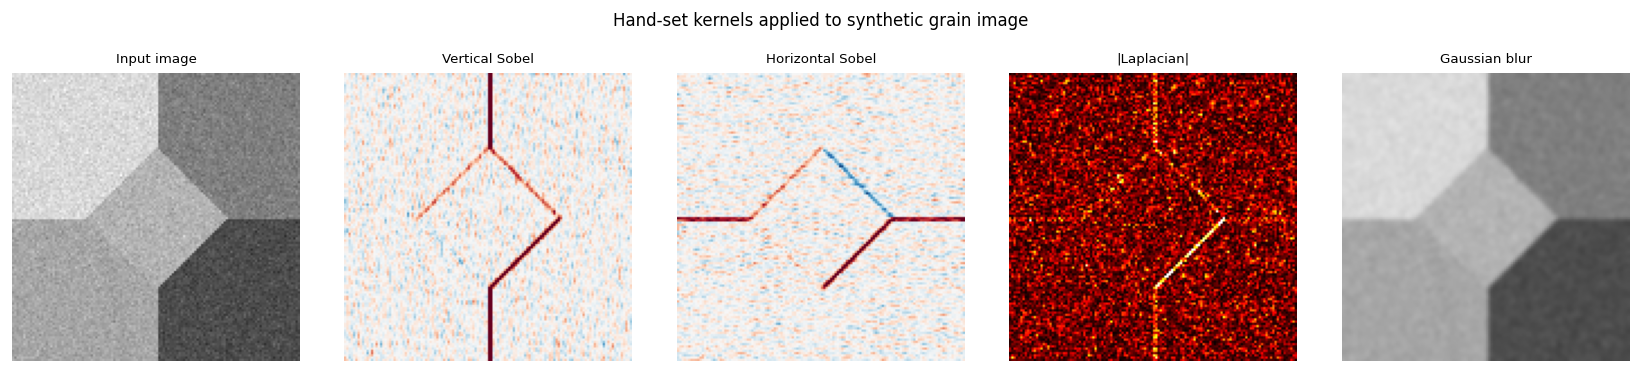

In [3]:
# ── Define hand-set kernels ───────────────────────────────────────────────
K_sobel_v = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)  # vertical edges

K_sobel_h = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float32)  # horizontal edges

K_laplace = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]], dtype=np.float32)  # any edge

# 5×5 Gaussian blur (hand-computed binomial weights, normalised)
_g1d = np.array([1, 4, 6, 4, 1], dtype=np.float32)
K_gaussian = np.outer(_g1d, _g1d)
K_gaussian /= K_gaussian.sum()  # normalise to preserve mean intensity

# ── Apply kernels ─────────────────────────────────────────────────────────
# scipy.ndimage.convolve applies the kernel to the image
feat_sv   = convolve(image, K_sobel_v,  mode='reflect')
feat_sh   = convolve(image, K_sobel_h,  mode='reflect')
feat_lap  = convolve(image, K_laplace,  mode='reflect')
feat_blur = convolve(image, K_gaussian, mode='reflect')

# ── Display ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
data = [
    (image,    'gray',   'Input image',         0.0, 1.0),
    (feat_sv,  'RdBu_r', 'Vertical Sobel',     -1.0, 1.0),
    (feat_sh,  'RdBu_r', 'Horizontal Sobel',   -1.0, 1.0),
    (np.abs(feat_lap), 'hot', '|Laplacian|',   0.0, 0.8),
    (feat_blur,'gray',   'Gaussian blur',        0.0, 1.0),
]
for ax, (d, cmap, title, vmin, vmax) in zip(axes, data):
    ax.imshow(d, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=8)
    ax.axis('off')
plt.suptitle('Hand-set kernels applied to synthetic grain image', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# (try this yourself) — change K_sobel_v to K_sobel_h and check which boundary lights up
# (try this yourself) — apply np.abs(feat_sv) + np.abs(feat_sh) to get all edges at once

**What you should see:**
- *Vertical Sobel* fires (red/blue) along the vertical grain boundaries (left–right contrast changes).
- *Horizontal Sobel* fires along the horizontal boundaries.
- *|Laplacian|* fires at all boundaries, roughly equally in all directions.
- *Gaussian blur* smooths the noise without changing the large-scale grain structure.

---

## Part 3 — Multiple kernels = multiple feature maps

A real CNN convolutional layer applies **many kernels simultaneously**, producing one feature map per kernel.  
The output tensor has shape $C_{out} \times H_{out} \times W_{out}$.

Let us stack our four kernels into one "layer" and compute all four feature maps at once using PyTorch's `F.conv2d`.

Input shape:        torch.Size([1, 1, 128, 128])   → (batch, channels, H, W)
Weight shape:       torch.Size([4, 1, 3, 3]) → (C_out, C_in, kH, kW)
Feature maps shape: torch.Size([1, 4, 128, 128]) → (batch, C_out, H, W)


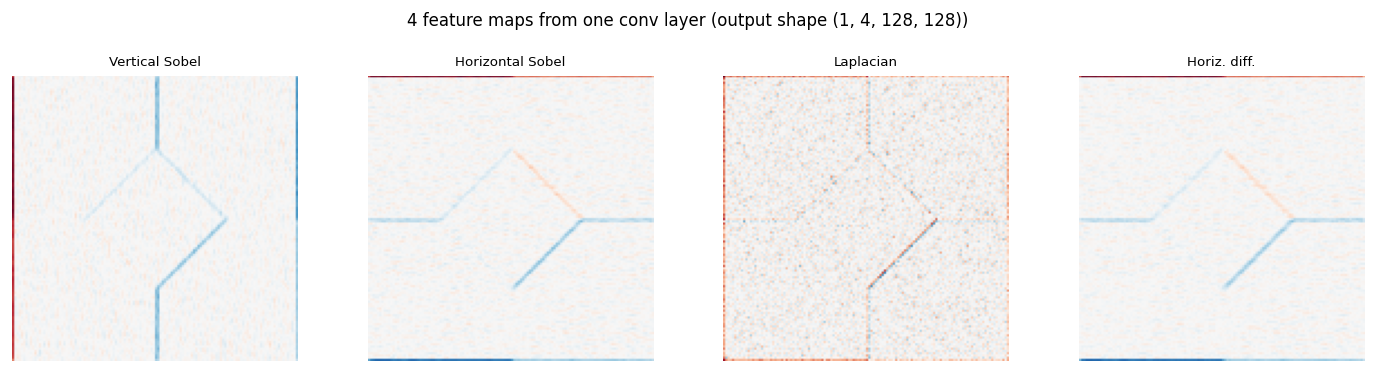

In [4]:
import torch.nn.functional as F

# ── Stack kernels into a weight tensor ──────────────────────────────────────
# PyTorch conv2d weight shape: (C_out, C_in, kH, kW)
# We have 4 kernels (C_out=4), 1 input channel (C_in=1), 3×3 kernels
kernels_3x3 = np.stack([
    K_sobel_v[np.newaxis],   # shape (1,3,3)
    K_sobel_h[np.newaxis],
    K_laplace[np.newaxis],
    np.array([[-1,-1,-1],[ 0, 0, 0],[ 1, 1, 1]], dtype=np.float32)[np.newaxis],  # horizontal difference
], axis=0)  # → (4, 1, 3, 3)

weight = torch.tensor(kernels_3x3)  # (4, 1, 3, 3)

# Image as (1, 1, H, W) tensor — batch size 1, 1 channel
x = torch.tensor(image[np.newaxis, np.newaxis])  # (1, 1, 128, 128)

# Apply convolution with padding=1 to preserve spatial size
with torch.no_grad():
    feat_maps = F.conv2d(x, weight, padding=1)  # (1, 4, 128, 128)

feat_maps_np = feat_maps[0].numpy()  # (4, 128, 128)

print(f'Input shape:        {x.shape}   → (batch, channels, H, W)')
print(f'Weight shape:       {weight.shape} → (C_out, C_in, kH, kW)')
print(f'Feature maps shape: {feat_maps.shape} → (batch, C_out, H, W)')

# ── Display ───────────────────────────────────────────────────────────────
names = ['Vertical Sobel', 'Horizontal Sobel', 'Laplacian', 'Horiz. diff.']
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, fm, name in zip(axes, feat_maps_np, names):
    vmax = max(np.abs(fm).max(), 0.01)
    ax.imshow(fm, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(name, fontsize=8)
    ax.axis('off')
plt.suptitle(f'4 feature maps from one conv layer (output shape {tuple(feat_maps.shape)})',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# (try this yourself) — change padding=1 to padding=0 and see how the output shape changes
# (try this yourself) — print feat_maps_np[0].shape to confirm the spatial dimensions are preserved

---

## Part 4 — Tiny CNN forward pass: shapes and receptive fields

Now we build a tiny randomly-initialised CNN in PyTorch and trace how tensor shapes change through the network.  
**No training happens** — we just do a forward pass with random weights to understand the architecture.

In [5]:
# ── Define a tiny CNN ──────────────────────────────────────────────────────
class TinyCNN(nn.Module):
    """A minimal classification CNN: two conv-pool blocks + a linear head.

    Block 1: Conv(1→8, 3×3, pad=1) + ReLU + MaxPool(2×2)  → (8, H/2, W/2)
    Block 2: Conv(8→16, 3×3, pad=1) + ReLU + MaxPool(2×2) → (16, H/4, W/4)
    Head:    Flatten → Linear(16 * (H/4) * (W/4) → num_classes)
    """
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Classifier head — size depends on input H, W
        # For 128×128 input: H/4 = 32, W/4 = 32 → 16*32*32 = 16384
        self.head = nn.Linear(16 * 32 * 32, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.flatten(start_dim=1)   # flatten all dims except batch
        x = self.head(x)
        return x


model = TinyCNN(in_channels=1, num_classes=5)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

TinyCNN(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Linear(in_features=16384, out_features=5, bias=True)
)

Total parameters: 83,173


Shape trace:
  Input:         (1, 1, 128, 128)
  After block 1: (1, 8, 64, 64)   (8 ch, 64×64 — MaxPool halved H,W)
  After block 2: (1, 16, 32, 32)  (16 ch, 32×32 — second MaxPool)
  Flattened:     (1, 16384)   (16×32×32 = 16384 features)
  Logits:        (1, 5)      (one score per class)


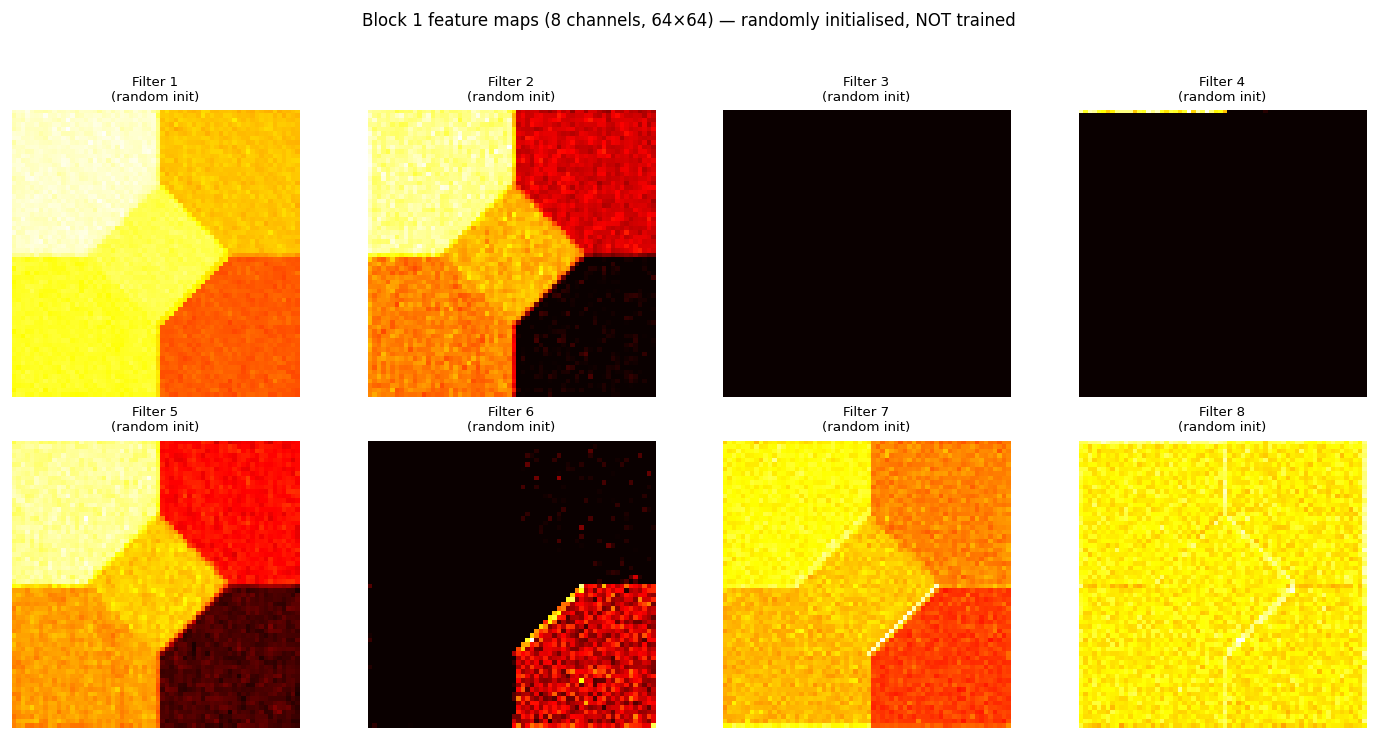

In [6]:
# ── Trace shapes through the forward pass ──────────────────────────────────
# Use a single 128×128 image (batch size 1)
x_in = torch.tensor(image[np.newaxis, np.newaxis])  # (1, 1, 128, 128)

with torch.no_grad():
    after_block1 = model.block1(x_in)         # after first conv-pool block
    after_block2 = model.block2(after_block1)  # after second conv-pool block
    flat         = after_block2.flatten(1)     # flattened feature vector
    logits       = model.head(flat)            # class scores

print('Shape trace:')
print(f'  Input:         {tuple(x_in.shape)}')
print(f'  After block 1: {tuple(after_block1.shape)}   (8 ch, 64×64 — MaxPool halved H,W)')
print(f'  After block 2: {tuple(after_block2.shape)}  (16 ch, 32×32 — second MaxPool)')
print(f'  Flattened:     {tuple(flat.shape)}   (16×32×32 = 16384 features)')
print(f'  Logits:        {tuple(logits.shape)}      (one score per class)')

# ── Visualise first-layer feature maps ─────────────────────────────────────
fm1 = after_block1[0].numpy()  # (8, 64, 64) — remove batch dim
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    vmax = max(fm1[i].max(), 0.01)
    ax.imshow(fm1[i], cmap='hot', vmin=0, vmax=vmax)
    ax.set_title(f'Filter {i+1}\n(random init)', fontsize=8)
    ax.axis('off')
plt.suptitle('Block 1 feature maps (8 channels, 64×64) — randomly initialised, NOT trained',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# (try this yourself) — change batch size to 4: x_batch = x_in.repeat(4,1,1,1)
#                        and check that logits shape becomes (4, 5)
# (try this yourself) — count parameters manually:
#                        block1 conv: 1*8*3*3 + 8 (biases) = ?
#                        block2 conv: 8*16*3*3 + 16 = ?
#                        head: 16*32*32*5 + 5 = ?
#                        check against model output above

---

## Exercise — Design a kernel to detect diagonal grain boundaries

The vertical Sobel fires at vertical (left–right) boundaries; the horizontal Sobel fires at horizontal (top–bottom) boundaries.  
Your task: design a 3×3 kernel that responds **strongly to diagonal (45°) boundaries** — specifically, boundaries where the upper-left region is bright and the lower-right region is dark.

**Instructions:**
1. Look at the working version below — understand what the weights are doing before running it.
2. Run the cell and inspect the feature map.
3. The `assert` statements check that your kernel has the expected properties — they must pass.
4. **(try this yourself)** — change the weights to detect the *opposite* diagonal (upper-right bright, lower-left dark) and verify the response changes.

**Hint:** A diagonal boundary from top-left to bottom-right has the property that pixels *above-left* of the boundary are brighter than pixels *below-right*. Your kernel should weight the top-left corner positively and the bottom-right corner negatively.

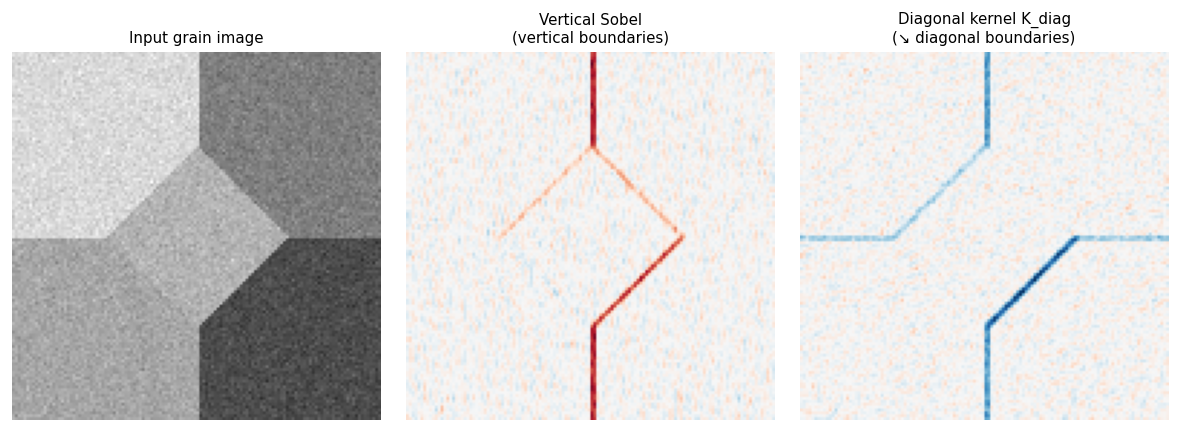

All assertions passed!
  Kernel sum       = 0.000000  (should be ~0)
  Test patch resp  = 4.0000   (should be > 0)
  Centre-strip max = 0.4503   (should be > corner mean)
  Corner mean      = 0.1066


In [7]:
# ── Exercise: diagonal boundary detector ─────────────────────────────────
#
# Working version — study before running.
# The kernel weights the top-left region positively (bright) and the
# bottom-right region negatively (dark), detecting a ↘ brightness drop.

K_diag = np.array([[ 2,  1,  0],
                   [ 1,  0, -1],
                   [ 0, -1, -2]], dtype=np.float32)

# Apply to the synthetic grain image
feat_diag = convolve(image, K_diag, mode='reflect')

# Visualise alongside vertical Sobel for comparison
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Input grain image', fontsize=9)

feat_v = convolve(image, K_sobel_v, mode='reflect')
vmax_v = np.abs(feat_v).max()
axes[1].imshow(feat_v, cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
axes[1].set_title('Vertical Sobel\n(vertical boundaries)', fontsize=9)

vmax_d = np.abs(feat_diag).max()
axes[2].imshow(feat_diag, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d)
axes[2].set_title('Diagonal kernel K_diag\n(↘ diagonal boundaries)', fontsize=9)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# ── Self-check assertions (must all pass) ──────────────────────────────────

# 1. Kernel shape must be 3×3
assert K_diag.shape == (3, 3), f"Expected (3,3), got {K_diag.shape}"

# 2. Kernel sum must be 0 (edge detectors have zero DC response — they
#    produce zero output on a uniform image, not a constant offset)
assert abs(K_diag.sum()) < 1e-5, (
    f"Kernel should sum to ~0 (DC-free), but sum = {K_diag.sum():.4f}. "
    "Hint: positive and negative weights should balance."
)

# 3. The kernel should fire POSITIVELY at a bright-top-left / dark-bottom-right edge.
#    Create a tiny test image: 3×3 patch, upper-left bright (1.0), lower-right dark (0.0)
test_patch = np.array([[1., 1., 0.],
                        [1., 0., 0.],
                        [0., 0., 0.]], dtype=np.float32)
response = (K_diag * test_patch).sum()
assert response > 0, (
    f"Kernel should respond positively to bright-upper-left / dark-lower-right patch, "
    f"but response = {response:.4f}. Check the sign of your weights."
)

# 4. Feature map shape must match input shape (because we used padding='reflect')
assert feat_diag.shape == image.shape, (
    f"Feature map shape {feat_diag.shape} != image shape {image.shape}"
)

# 5. The diagonal feature map maximum should be meaningfully larger
#    near the diagonal-ish grain boundary (centre of image) than at
#    the corners of the grain interior.
#    Check: max response in a 20-pixel strip around the image centre
#    is larger than the mean response in the four corner 30×30 blocks.
centre_strip = feat_diag[54:74, 54:74]
corner_mean = np.mean([
    np.abs(feat_diag[:30, :30]).mean(),
    np.abs(feat_diag[:30, -30:]).mean(),
    np.abs(feat_diag[-30:, :30]).mean(),
    np.abs(feat_diag[-30:, -30:]).mean(),
])
centre_max = np.abs(centre_strip).max()
assert centre_max > corner_mean, (
    f"Expected stronger diagonal response near centre ({centre_max:.4f}) "
    f"than in corners ({corner_mean:.4f}). Check your kernel design."
)

print("All assertions passed!")
print(f"  Kernel sum       = {K_diag.sum():.6f}  (should be ~0)")
print(f"  Test patch resp  = {response:.4f}   (should be > 0)")
print(f"  Centre-strip max = {centre_max:.4f}   (should be > corner mean)")
print(f"  Corner mean      = {corner_mean:.4f}")

# (try this yourself) — flip the sign: K_diag_flip = -K_diag
#                        apply it and see where it fires now
# (try this yourself) — design K_diag2 for the OTHER diagonal (↗ direction)
#                        hint: the weights should be on the anti-diagonal

---

### Solution

*(Non-executable — read only after you have run the exercise cell.)*

```python
# A working diagonal kernel for the ↘ direction (upper-left bright, lower-right dark):
K_diag = np.array([[ 2,  1,  0],
                   [ 1,  0, -1],
                   [ 0, -1, -2]], dtype=np.float32)
# Sum = 0 ✓  (2+1+1+0+0+0-1-1-2 = 0)
# Test patch response = 2*1 + 1*1 + 1*1 + 0 + ... = positive ✓

# For the OTHER diagonal (↗ direction, upper-right bright, lower-left dark):
K_diag2 = np.array([[ 0,  1,  2],
                    [-1,  0,  1],
                    [-2, -1,  0]], dtype=np.float32)
# This is K_diag flipped left-right: np.fliplr(K_diag)
```

---

## Part 5 — Receptive field inspection

A single output neuron in a stacked CNN sees a larger region of the input than a single conv layer.  
Let us verify this by computing which input pixels influence a specific output pixel.

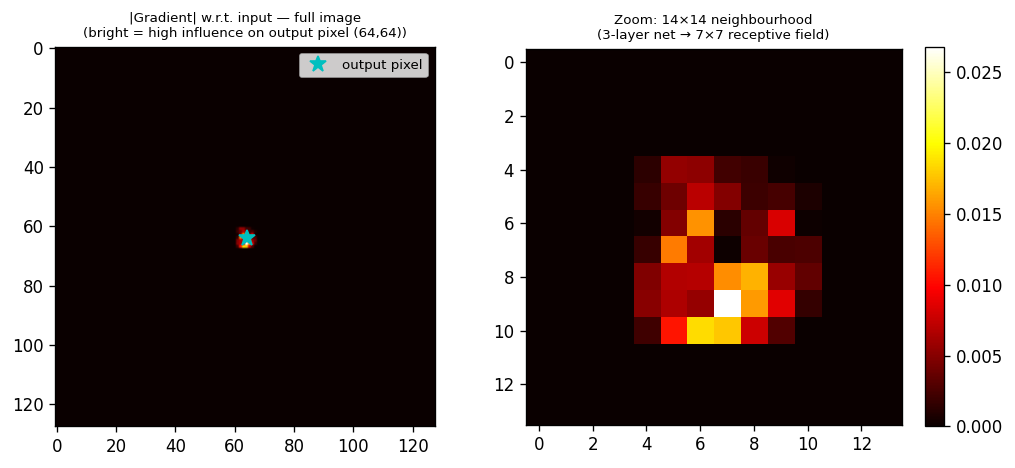

Receptive field measured from gradient: 7×7
Expected for 3 stacked 3×3 conv layers: 7×7


In [8]:
# ── Receptive field by backpropagating a 1-hot output ─────────────────────
# Build a simple 3-layer conv-only network (no pooling, for clarity)
# so we can trace the receptive field

class ThreeLayerConvNet(nn.Module):
    """Three stacked 3×3 conv layers, padding=1, stride=1 throughout.
    Receptive field of one output neuron = 7×7 in the input.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(4, 4, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(4, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.conv3(x)   # no activation on final layer
        return x

net3 = ThreeLayerConvNet()

# Input requires gradient so we can trace which input pixels had influence
x_rf = torch.tensor(image[np.newaxis, np.newaxis], requires_grad=True)

out = net3(x_rf)   # (1, 1, 128, 128)

# Select one specific output neuron: position (64, 64) in the centre
# Backpropagate a scalar = 1.0 from that neuron
out[0, 0, 64, 64].backward()

# The gradient of the input tells us which input pixels affected this output
rf_map = x_rf.grad[0, 0].abs().detach().numpy()

# Zoom into a 20×20 window centred on the output location
crop = rf_map[57:71, 57:71]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(rf_map, cmap='hot')
axes[0].set_title('|Gradient| w.r.t. input — full image\n(bright = high influence on output pixel (64,64))',
                   fontsize=8)
axes[0].plot(64, 64, 'c*', ms=10, label='output pixel')
axes[0].legend(fontsize=8)

im = axes[1].imshow(crop, cmap='hot')
axes[1].set_title('Zoom: 14×14 neighbourhood\n(3-layer net → 7×7 receptive field)', fontsize=8)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

# Compute the receptive field size from the gradient support
nonzero = rf_map > rf_map.max() * 1e-6
rows = np.any(nonzero, axis=1)
cols = np.any(nonzero, axis=0)
rf_h = rows.sum()
rf_w = cols.sum()
print(f'Receptive field measured from gradient: {rf_h}×{rf_w}')
print(f'Expected for 3 stacked 3×3 conv layers: 7×7')

# (try this yourself) — change the network to use only 2 conv layers
#                        and re-run: what receptive field do you expect? (5×5)
# (try this yourself) — add stride=2 to conv2 and check the output shape
#                        and how the receptive field changes

---

## Summary

| Concept | What you did | Key number |
|---|---|---|
| Sliding feature detector | Applied Sobel/Laplacian kernels | 3×3 kernel = 9 parameters |
| Weight sharing | Same kernel used at every pixel | 576 params vs ~537M for MLP |
| Feature maps | 4 kernels → 4 feature maps simultaneously | Shape (1, 4, 128, 128) |
| CNN forward pass | Traced shapes through TinyCNN | (1,1,128,128) → (1,5) |
| Receptive field | Measured via gradient | 3 layers × 3×3 → 7×7 |
| Kernel design | Designed diagonal boundary detector | DC-free, passes 4 asserts |

**Next week (Week 7):** you will see how to train a CNN like TinyCNN on real EM data using data augmentation and transfer learning — overcoming the challenge of small labelled datasets.

---

*Data Science for Electron Microscopy — Week 6 self-study notebook*  
*Prof. Dr. Philipp Pelz — FAU Erlangen-Nürnberg*